## Required Imports

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from tqdm.notebook import tqdm
from torchvision.datasets import MNIST  # using MNIST for simple demonstration
from sklearn.decomposition import PCA

## Data Transforms

In [2]:
transform = transforms.Compose(
    [
        transforms.Resize((32, 32)), # for MNIST dataset, we resize the image to 32x32 for convenience purpose
        transforms.ToTensor(), # convert the image to a tensor  
    ]
)

# load the MNIST dataset
train_dataset = MNIST(root='../../data', train=True, download=True, transform=transform)
test_dataset = MNIST(root='../../data', train=False, download=True, transform=transform)

## Set the Device

In [3]:
# define the device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Exploring the Data

In [4]:
for image, label in train_dataset:
    print('-'*100)
    print('Basic Image Stats:')
    print(f'Image shape: {image.shape}.')
    print(f'Label: {label}.')
    print(f'Image min: {image.min()}.')
    print(f'Image max: {image.max()}.')
    print('-'*100)
    print(f'Image pixels:\n {image}.')
    print('-'*100)
    break

----------------------------------------------------------------------------------------------------
Basic Image Stats:
Image shape: torch.Size([1, 32, 32]).
Label: 5.
Image min: 0.0.
Image max: 0.9921568632125854.
----------------------------------------------------------------------------------------------------
Image pixels:
 tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]]).
----------------------------------------------------------------------------------------------------


## The Vanilla Autoencoder

In [5]:
class Autoencoder(nn.Module):
    """A simple autoencoder model. The encoder network is a stack of linear layers with ReLU activation functions
    as nonlinearities. The autoencoder network is trained to learn a compressed representation of the data.
    """
    def __init__(self, bottleneck_size: int=2):
        super(Autoencoder, self).__init__()
        
        self.encoder = nn.Sequential(
            nn.Linear(32 * 32, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, bottleneck_size)
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_size, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 32 * 32),
            nn.Sigmoid() # ensure the output is in the range [0, 1] for visualization and reconstruction
                         # to ensure the output is in the range [-1, 1], we can use nn.Tanh() instead of nn.Sigmoid()
        )
    
    def encode(self, x):
        """Encoder function to encode the image to a latent space.
        """
        return self.encoder(x)
    
    def decode(self, x):
        """Decoder function to decode the latent space to an image.
        """
        x = self.decoder(x)
        x = x.reshape(-1, 1, 32, 32) # reshape the output to the original image shape
        return x
    
    def forward(self, x):
        b, c, h, w = x.shape

        x = x.flatten(start_dim=1) # flatten the image to a 1D vector starting from the second dimension

        encoded = self.encode(x) # encode the image to a latent space
        decoded = self.decode(encoded) # decode the latent space to an image

        return encoded, decoded

### A Simple Forward Pass

In [6]:
model = Autoencoder()
rand = torch.randn(2, 1, 32, 32)
model(rand)

(tensor([[ 0.1318, -0.0290],
         [ 0.1446, -0.0159]], grad_fn=<AddmmBackward0>),
 tensor([[[[0.4872, 0.5038, 0.5227,  ..., 0.4975, 0.4909, 0.4623],
           [0.5141, 0.5180, 0.4727,  ..., 0.4836, 0.5026, 0.5259],
           [0.4799, 0.5251, 0.4941,  ..., 0.4889, 0.5163, 0.5267],
           ...,
           [0.4998, 0.4765, 0.5173,  ..., 0.4921, 0.4851, 0.4938],
           [0.5247, 0.4879, 0.4867,  ..., 0.5250, 0.5119, 0.5120],
           [0.5043, 0.5020, 0.4957,  ..., 0.5068, 0.5103, 0.4762]]],
 
 
         [[[0.4872, 0.5038, 0.5228,  ..., 0.4974, 0.4910, 0.4621],
           [0.5140, 0.5180, 0.4726,  ..., 0.4836, 0.5026, 0.5260],
           [0.4799, 0.5251, 0.4940,  ..., 0.4889, 0.5164, 0.5266],
           ...,
           [0.4999, 0.4765, 0.5173,  ..., 0.4921, 0.4851, 0.4940],
           [0.5248, 0.4882, 0.4868,  ..., 0.5252, 0.5121, 0.5122],
           [0.5041, 0.5017, 0.4957,  ..., 0.5069, 0.5104, 0.4761]]]],
        grad_fn=<ViewBackward0>))

## Training

In [7]:
def train(
    model: nn.Module,
    train_dataset: Dataset,
    test_dataset: Dataset,
    batch_size: int,
    training_iterations: int,
    eval_iterations: int
    ):

        print("Training the model...")
        print(model)

        model  = model.to(device)

        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

        optimizer = optim.Adam(model.parameters(), lr=0.0005)

        train_loss = []
        eval_loss = []
        train_losses = []
        eval_losses = []

        encoded_data_per_eval = []

        pbar = tqdm(range(training_iterations), desc="Training")
        last_eval_loss = None

        train = True

        global_step = 0

        while train:
            model.train()
            for images, labels in train_loader:
                images = images.to(device)

                optimizer.zero_grad()
                
                encoded, recon = model(images)

                loss = torch.mean((images - recon) ** 2) # compute the mean squared error
                train_loss.append(loss.item())

                loss.backward()
                optimizer.step()

                if global_step % eval_iterations == 0:
                    model.eval()
                    encoded_evals = []

                    for images, labels in test_loader:

                        with torch.no_grad():
                            images = images.to(device)
                        
                        encoded, recon = model(images)

                        loss = torch.mean((images - recon) ** 2)
                        eval_loss.append(loss.item())

                        # store the encoded data and the labels
                        encoded, labels = encoded.cpu().flatten(1), labels.reshape(-1, 1)
                        encoded_evals.append(torch.cat((encoded, labels), axis=-1))
                    
                    encoded_data_per_eval.append(torch.concatenate(encoded_evals).detach())
                    
                    train_loss = np.mean(train_loss)
                    eval_loss = np.mean(eval_loss)
                    last_eval_loss = eval_loss
                    
                    train_losses.append(train_loss)
                    eval_losses.append(eval_loss)

                    print(f'training loss: {train_loss:.4f}, eval loss: {eval_loss:.4f}')
                    
                    # reset the loss values for the next evaluation
                    train_loss = []
                    eval_loss = []
                
                global_step += 1
                pbar.update(1)

                if global_step >= training_iterations:
                    print("Training complete.")
                    train = False
                    break
        
        # store the encoded data as numpy arrays for each evaluation
        encoded_data_per_eval = [i.numpy() for i in encoded_data_per_eval]  # convert tensors to numpy (avoids np.array deprecation with PyTorch)

        return model, train_losses, eval_losses, encoded_data_per_eval

In [8]:
# start with a fresh model
vanilla_autoencoder = Autoencoder(bottleneck_size=2)

In [9]:
vanilla_autoencoder, train_losses, eval_losses, vanilla_autoencoder_encoded_data_per_eval = train(
    vanilla_autoencoder,
    train_dataset,
    test_dataset,
    batch_size=64,
    training_iterations=5000,
    eval_iterations=250)

Training the model...
Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=1024, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=2, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=1024, bias=True)
    (7): Sigmoid()
  )
)


Training:   0%|          | 0/5000 [00:00<?, ?it/s]

training loss: 0.2188, eval loss: 0.2188
training loss: 0.0745, eval loss: 0.0541
training loss: 0.0498, eval loss: 0.0469
training loss: 0.0459, eval loss: 0.0449
training loss: 0.0444, eval loss: 0.0441
training loss: 0.0432, eval loss: 0.0430
training loss: 0.0423, eval loss: 0.0423
training loss: 0.0417, eval loss: 0.0412
training loss: 0.0407, eval loss: 0.0404
training loss: 0.0395, eval loss: 0.0396
training loss: 0.0387, eval loss: 0.0382
training loss: 0.0377, eval loss: 0.0375
training loss: 0.0373, eval loss: 0.0370
training loss: 0.0367, eval loss: 0.0366
training loss: 0.0361, eval loss: 0.0362
training loss: 0.0359, eval loss: 0.0358
training loss: 0.0354, eval loss: 0.0355
training loss: 0.0352, eval loss: 0.0352
training loss: 0.0350, eval loss: 0.0350
training loss: 0.0348, eval loss: 0.0349
Training complete.


## Plot the Embedding Space through Training

Now we can write a function that takes in the `encoded_data_per_eval` from the training output, and create an animation of the embedding space to see how the neural network learns. Note that the first two columns of the `encoded_data_per_eval` denote the principal component axes where the model decides to place the embeddings, and the last column denotes the corresponding class labels of the embeddings.

In [10]:
print(vanilla_autoencoder_encoded_data_per_eval[0])

[[0.10299952 0.12079634 7.        ]
 [0.09791942 0.13065931 2.        ]
 [0.10704595 0.11303734 1.        ]
 ...
 [0.11113666 0.13499242 4.        ]
 [0.12073603 0.1406739  5.        ]
 [0.09729512 0.14511122 6.        ]]


In [11]:
from matplotlib.animation import FuncAnimation, PillowWriter

def generate_embedding_animation(
    encodings: np.ndarray | list[np.ndarray],
    title: str = "Autoencoder Embedding Space",
    *,
    output_path: str = "results/embedding_progression.gif",
    eval_iterations: int = 250,
    fps: int = 4,
):
    """
    Generate a static plot or GIF of the embedding space.
    Pass a single array for a static plot, or a list of arrays for a GIF.
    """
    def _plot_frame(ax, data: np.ndarray, frame_title: str, x_lim=None, y_lim=None):
        df = pd.DataFrame(data, columns=["x", "y", "class"])
        df = df.sort_values(by="class")
        df["class"] = df["class"].astype(int).astype(str)
        for label, coordinates in df.groupby("class"):
            ax.scatter(x=coordinates["x"], y=coordinates["y"], label=label, alpha=0.8, s=5)
        ax.set_title(frame_title)
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        if x_lim is not None:
            ax.set_xlim(x_lim)
        if y_lim is not None:
            ax.set_ylim(y_lim)
        ax.legend()

    if isinstance(encodings, np.ndarray):
        # Single frame - static plot
        fig, ax = plt.subplots(figsize=(8, 6))
        _plot_frame(ax, encodings, title)
        plt.show()
    else:
        # List of frames - GIF
        path = output_path
        output_dir = os.path.dirname(path)
        if output_dir:
            os.makedirs(output_dir, exist_ok=True)

        all_x = np.concatenate([d[:, 0] for d in encodings])
        all_y = np.concatenate([d[:, 1] for d in encodings])
        x_margin = (all_x.max() - all_x.min()) * 0.05 or 0.1
        y_margin = (all_y.max() - all_y.min()) * 0.05 or 0.1
        x_lim = (all_x.min() - x_margin, all_x.max() + x_margin)
        y_lim = (all_y.min() - y_margin, all_y.max() + y_margin)

        fig, ax = plt.subplots(figsize=(8, 6))

        def update(frame_idx: int):
            ax.clear()
            step = (frame_idx + 1) * eval_iterations
            _plot_frame(ax, encodings[frame_idx], f"Embedding Space at Step {step}", x_lim, y_lim)

        anim = FuncAnimation(fig, update, frames=len(encodings), interval=1000 // fps)
        anim.save(path, writer=PillowWriter(fps=fps))
        plt.close()
        print(f"GIF saved to {path}")

In [12]:
# Generate GIF of training progression
generate_embedding_animation(
    vanilla_autoencoder_encoded_data_per_eval,
    output_path="results/embedding_progression.gif",
    eval_iterations=250,
)

GIF saved to results/embedding_progression.gif


In [13]:
# Quick check: list generated animation files
from pathlib import Path

results_dir = Path("results")
if not results_dir.exists():
    print("results/ does not exist yet. Run an animation cell first.")
else:
    gif_files = sorted(results_dir.glob("*.gif"))
    if not gif_files:
        print("No GIF files found in results/.")
    else:
        print("Generated GIFs:")
        for gif_path in gif_files:
            size_kb = gif_path.stat().st_size / 1024
            print(f"- {gif_path} ({size_kb:.1f} KB)")

Generated GIFs:
- results/embedding_progression.gif (841.7 KB)
- results/linear_autoencoder_embedding.gif (4221.4 KB)


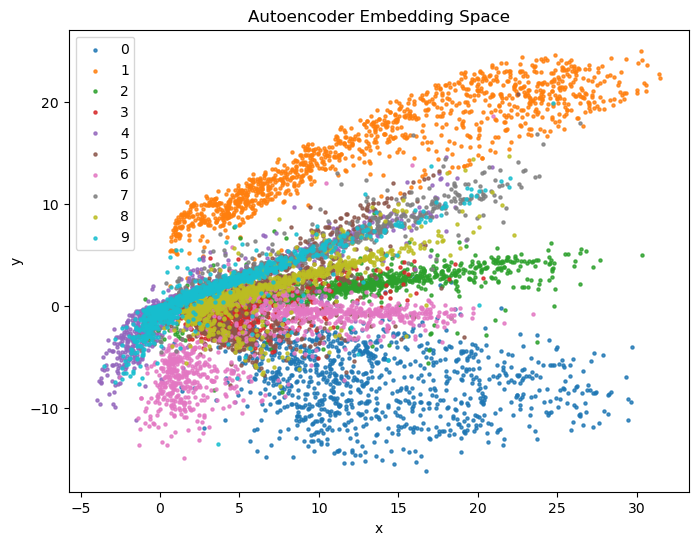

In [14]:
generate_embedding_animation(vanilla_autoencoder_encoded_data_per_eval[-1], "Autoencoder Embedding Space")

The above plot demonstrates the compressed latent space of the model. If we take a look at the plot and the corresponding labels, we can see some effects of clustering here, for instance, the points representing "4"(purple) and "9" (blue) are very close to each other, coincide with their visual appearances.

Now let's see the progression.

![Embedding progression](results/embedding_progression.gif)

## A Linear Autoencoder is Just Another PCA

In [15]:
class LinearAutoencoder(nn.Module):
    def __init__(self, bottleneck_size: int=2):
        """
        A linear autoencoder with simple linear layers to compress and decompress the images.
        """
        super(LinearAutoencoder, self).__init__()

        self.encoder = nn.Linear(32 * 32, bottleneck_size)
        self.decoder = nn.Linear(bottleneck_size, 32 * 32)
    
    def forward(self, x):
        x = x.flatten(start_dim=1)

        encoded = self.encoder(x)
        decoded = self.decoder(encoded)

        decoded = decoded.reshape(-1, 1, 32, 32) # reshape the output to the original image shape

        return encoded, decoded

In [16]:
linear_autoencoder = LinearAutoencoder(bottleneck_size=2) # initialize the model

### Training the Linear Autoencoder

In [17]:
linear_autoencoder, train_losses, eval_losses, linear_autoencoder_encoded_data_per_eval = train(linear_autoencoder, train_dataset, test_dataset, batch_size=64, training_iterations=25000, eval_iterations=250)

Training the model...
LinearAutoencoder(
  (encoder): Linear(in_features=1024, out_features=2, bias=True)
  (decoder): Linear(in_features=2, out_features=1024, bias=True)
)


Training:   0%|          | 0/25000 [00:00<?, ?it/s]

training loss: 0.2843, eval loss: 0.2739
training loss: 0.2142, eval loss: 0.1616
training loss: 0.1212, eval loss: 0.0927
training loss: 0.0764, eval loss: 0.0664
training loss: 0.0613, eval loss: 0.0587
training loss: 0.0573, eval loss: 0.0566
training loss: 0.0557, eval loss: 0.0559
training loss: 0.0557, eval loss: 0.0557
training loss: 0.0551, eval loss: 0.0555
training loss: 0.0552, eval loss: 0.0554
training loss: 0.0551, eval loss: 0.0553
training loss: 0.0549, eval loss: 0.0551
training loss: 0.0549, eval loss: 0.0550
training loss: 0.0545, eval loss: 0.0548
training loss: 0.0544, eval loss: 0.0546
training loss: 0.0543, eval loss: 0.0544
training loss: 0.0540, eval loss: 0.0541
training loss: 0.0537, eval loss: 0.0538
training loss: 0.0533, eval loss: 0.0535
training loss: 0.0534, eval loss: 0.0531
training loss: 0.0526, eval loss: 0.0528
training loss: 0.0522, eval loss: 0.0524
training loss: 0.0522, eval loss: 0.0520
training loss: 0.0520, eval loss: 0.0516
training loss: 0

In [18]:
generate_embedding_animation(
    linear_autoencoder_encoded_data_per_eval,
    title="Linear Autoencoder Embedding Space",
    output_path="results/linear_autoencoder_embedding.gif",
    eval_iterations=250,
)

GIF saved to results/linear_autoencoder_embedding.gif


### Compare to PCA

In [19]:
display(test_dataset[0])
display(test_dataset[0][0].shape)

(tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]]),
 7)

torch.Size([1, 32, 32])

As from above, there are two entries of each data sample in the test dataset, with each image stored as a $1 \times 32 \times 32$ tensor.

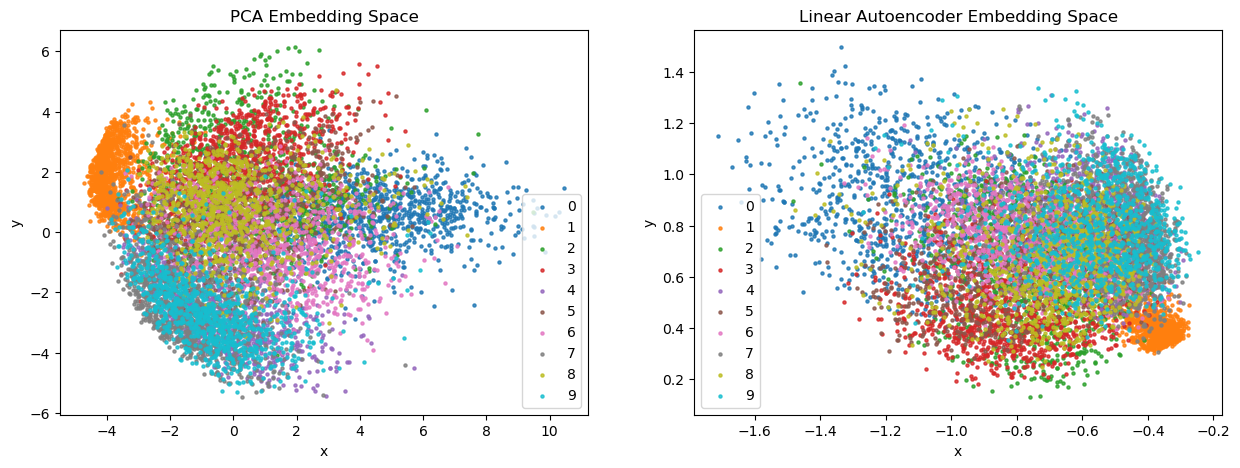

In [20]:
# convert the data in the test dataset to numpy arrays
data = torch.cat([d[0].flatten(1) for d in test_dataset], dim=0).numpy()
labels = np.array([test_sample[1] for test_sample in test_dataset]).reshape(-1, 1)

# compute PCA encodings (add label column so we have x, y, class like autoencoder encodings)
pca = PCA(n_components=2)
pca_encodings = pca.fit_transform(data)
pca_encodings = np.concatenate((pca_encodings, labels), axis=-1)
pca_encodings = pd.DataFrame(pca_encodings, columns=["x", "y", "class"])
pca_encodings = pca_encodings.sort_values(by="class")
pca_encodings["class"] = pca_encodings["class"].astype(int).astype(str)

# get the last row of Linear Autoencoder encodings
linear_autoencoder_encodings = linear_autoencoder_encoded_data_per_eval[-1]
linear_autoencoder_encodings = pd.DataFrame(linear_autoencoder_encodings, columns=["x", "y", "class"])
linear_autoencoder_encodings = linear_autoencoder_encodings.sort_values(by="class")
linear_autoencoder_encodings["class"] = linear_autoencoder_encodings["class"].astype(int).astype(str)

# plot the PCA and Linear Autoencoder encodings
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# plot PCA encodings
for label, coordinates in pca_encodings.groupby("class"):
    ax1.scatter(x=coordinates["x"], y=coordinates["y"], label=label, alpha=0.8, s=5)
ax1.set_title("PCA Embedding Space")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.legend()

for label, coordinates in linear_autoencoder_encodings.groupby("class"):
    ax2.scatter(x=coordinates["x"], y=coordinates["y"], label=label, alpha=0.8, s=5)
ax2.set_title("Linear Autoencoder Embedding Space")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.legend()

plt.show()

We can tell that the two embedding space looks very similar, and demonstrates we can essentially use linear autoencoder to mimic the behavior of the PCA model. Now let's check the principle components of PCA,

In [21]:
pca.components_

array([[ 4.4539452e-09, -4.3738937e-09, -8.0809431e-10, ...,
        -0.0000000e+00, -0.0000000e+00, -0.0000000e+00],
       [-2.8069586e-08,  1.9668306e-08,  1.8095787e-09, ...,
         0.0000000e+00,  0.0000000e+00,  0.0000000e+00]],
      shape=(2, 1024), dtype=float32)

In [22]:
pca.components_.shape

(2, 1024)

Essentially it's like a transformation matrix that takes in a $1024$-dimensional vector and converts it to a $2$-dimensional vector, which is just like what we do in the linear autoencoder,

```python
class LinearAutoencoder(nn.Module):
    def __init__(self, bottleneck_size=2):
        super(LinearAutoencoder, self).__init__()
        self.encoder = nn.Linear(32 * 32, bottleneck_size)
        # weight matrix: 1024 x 2
        # ...
```

The principle components of PCA should be orthogonal,

In [23]:
principle_component1, principle_component2 = torch.tensor(pca.components_[0]), torch.tensor(pca.components_[1])

print(f'Angle between principle components: {torch.rad2deg(torch.acos(torch.dot(principle_component1, principle_component2)))} degrees')

print(f'Norm of principle component 1: {torch.norm(principle_component1):.4f}')
print(f'Norm of principle component 2: {torch.norm(principle_component2):.4f}')

Angle between principle components: 90.0 degrees
Norm of principle component 1: 1.0000
Norm of principle component 2: 1.0000


Now let's check the linear autoencoder,

In [24]:
# Handle both LinearAutoencoder (nn.Linear encoder) and Sequential-based encoders
if isinstance(linear_autoencoder.encoder, nn.Sequential):
    model_weights = linear_autoencoder.encoder[0].weight
else:
    model_weights = linear_autoencoder.encoder.weight

model_weights.shape

torch.Size([2, 1024])

So yes, as expected, the model weight matrix of the linear autoencoder is of the same shape as the PCA transformation matrix.

In [25]:
weight_vector1, weight_vector2 = model_weights[0], model_weights[1]

print(f'Angle between weight vectors: {torch.rad2deg(torch.acos(torch.dot(weight_vector1, weight_vector2)))} degrees')

print(f'Norm of weight vector 1: {torch.norm(weight_vector1):.4f}')
print(f'Norm of weight vector 2: {torch.norm(weight_vector2):.4f}')


Angle between weight vectors: 88.908935546875 degrees
Norm of weight vector 1: 0.3999
Norm of weight vector 2: 0.3696


So they are orthogonal but not necessarily unit norm. But we can make them so,

In [26]:
weight_vector1, weight_vector2 = weight_vector1 / torch.norm(weight_vector1), weight_vector2 / torch.norm(weight_vector2)

print(f'Angle between weight vectors: {torch.rad2deg(torch.acos(torch.dot(weight_vector1, weight_vector2)))} degrees')

print(f'Norm of weight vector 1: {torch.norm(weight_vector1):.4f}')
print(f'Norm of weight vector 2: {torch.norm(weight_vector2):.4f}')


Angle between weight vectors: 82.59772491455078 degrees
Norm of weight vector 1: 1.0000
Norm of weight vector 2: 1.0000


It's still almost orthogonal, and will get closer after training longer.

However, for PCA, either the Eigenvalue Decomposition or Singular Value Decomposition method is expensive, and also note that classical matrix inversion is a very expensive operation, hence it's often a good idea to use neural networks to iteratively refine to an ideal approximation.

## Convolutional Autoencoder

Animations of Convolution and Deconvolution: https://hannibunny.github.io/mlbook/neuralnetworks/convolutionDemos.html

The convolution operation in neural networks offer an efficient way of downsampling, while transpose convolution offers an efficient way of upsampling.

In [27]:
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from tqdm.notebook import tqdm

In [28]:
rand = torch.randn(2, 3, 64, 64)

conv = nn.Conv2d(in_channels=3, out_channels=3, kernel_size=3, stride=2, padding=1)

conv(rand).shape

torch.Size([2, 3, 32, 32])

Here we go the downsampling.

In [29]:
conv_transpose = nn.ConvTranspose2d(in_channels=3, out_channels=3, kernel_size=3, stride=2, padding=1)

conv_transpose(conv(rand)).shape

torch.Size([2, 3, 63, 63])

The dimension doesnt work out as there's actually a floor function in the `Conv2d` operation: https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html.

In [30]:
random_tensor1 = torch.randn(2, 3, 64, 64)
random_tensor2 = torch.randn(2, 3, 63, 63)

print(conv(random_tensor1).shape)
print(conv(random_tensor2).shape)

torch.Size([2, 3, 32, 32])
torch.Size([2, 3, 32, 32])


In [31]:
conv_transpose = nn.ConvTranspose2d(in_channels=3, out_channels=3, kernel_size=3, stride=2, padding=1, output_padding=1)

conv_transpose(conv(rand)).shape

torch.Size([2, 3, 64, 64])

Now let's define the convolutional autoencoder,

In [32]:
class ConvolutionalAutoencoder(nn.Module):
    def __init__(self, in_channels: int=1, channels_bottleneck: int=4):
        super(ConvolutionalAutoencoder, self).__init__()

        self.bottleneck = channels_bottleneck
        self.in_channels = in_channels

        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels=in_channels, out_channels=8, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(8),  # this will remove the bias term
            nn.ReLU(),

            nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU(),

            nn.Conv2d(in_channels=16, out_channels=self.bottleneck, kernel_size=3, stride=2, padding=1, bias=False) # the last convolution layer is just a projection layer
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(in_channels=self.bottleneck, out_channels=16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),

            nn.ConvTranspose2d(in_channels=16, out_channels=8, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(8),
            nn.ReLU(),

            nn.ConvTranspose2d(in_channels=8, out_channels=self.in_channels, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()  # no need to batch norm as the output is in the range [0, 1]
        )
         
    
    def encode(self, x):
        return self.encoder(x)
    
    def decode(self, x):
        return self.decoder(x)

    def forward(self, x):
        batch_size, num_channels, height, width = x.shape
        encoded = self.encode(x)
        decoded = self.decode(encoded)

        return encoded, decoded

In [33]:
rand = torch.randn(2, 1, 32, 32)
model = ConvolutionalAutoencoder()
model(rand)

(tensor([[[[ 3.0266e-02,  1.4598e-02,  1.8988e-01, -2.1919e-01],
           [-7.9058e-02, -2.4088e-01, -3.1246e-01, -2.1684e-01],
           [ 3.0949e-01, -3.5212e-01, -1.9037e-01, -1.1179e-02],
           [ 1.7814e-01,  1.3154e-01,  5.8478e-01, -9.1545e-01]],
 
          [[-2.4005e-01,  1.6891e-01,  1.2728e-01,  3.3355e-01],
           [-1.1700e-01, -6.6931e-01, -6.8472e-01,  4.0330e-01],
           [-4.4745e-02,  7.5441e-01,  6.8268e-02, -4.1275e-01],
           [-1.7331e-01, -2.5792e-01, -2.3355e-01, -8.6263e-01]],
 
          [[-6.2370e-02,  2.0657e-01,  4.9941e-02, -2.2318e-01],
           [ 1.4625e-01,  2.1990e-02, -2.6240e-01, -5.5787e-01],
           [-1.2680e-03, -6.5866e-02,  2.7422e-02,  1.6034e-01],
           [-3.1570e-01, -3.9382e-01, -8.1939e-02,  2.1206e-01]],
 
          [[ 5.7522e-01,  1.2280e-01,  2.9974e-01, -4.4307e-01],
           [ 6.3469e-01,  4.8494e-01,  2.5832e-01,  5.5686e-02],
           [ 7.3545e-01, -3.8921e-01,  1.1720e-01, -1.0379e-01],
           [ 3.0

In [34]:
convolutional_autoencoder = ConvolutionalAutoencoder()
convolutional_autoencoder, train_losses, eval_losses, convolutional_autoencoder_encoded_data_per_eval = train(
    convolutional_autoencoder,
    train_dataset,
    test_dataset,
    batch_size=64,
    training_iterations=25000,
    eval_iterations=250
)

Training the model...
ConvolutionalAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(8, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv2d(16, 4, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(4, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): ConvTranspose2d(16, 8, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (4): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Co

Training:   0%|          | 0/25000 [00:00<?, ?it/s]

training loss: 0.2491, eval loss: 0.2228
training loss: 0.1534, eval loss: 0.0661
training loss: 0.0426, eval loss: 0.0263
training loss: 0.0195, eval loss: 0.0152
training loss: 0.0339, eval loss: 0.0716
training loss: 0.0149, eval loss: 0.0118
training loss: 0.0113, eval loss: 0.0103
training loss: 0.0100, eval loss: 0.0093
training loss: 0.0216, eval loss: 0.0205
training loss: 0.0101, eval loss: 0.0088
training loss: 0.0087, eval loss: 0.0081
training loss: 0.0081, eval loss: 0.0076
training loss: 0.0123, eval loss: 0.0101
training loss: 0.0080, eval loss: 0.0073
training loss: 0.0073, eval loss: 0.0069
training loss: 0.0070, eval loss: 0.0066
training loss: 0.0086, eval loss: 0.0074
training loss: 0.0068, eval loss: 0.0064
training loss: 0.0065, eval loss: 0.0061
training loss: 0.0066, eval loss: 0.0069
training loss: 0.0064, eval loss: 0.0060
training loss: 0.0061, eval loss: 0.0058
training loss: 0.0059, eval loss: 0.0057
training loss: 0.0063, eval loss: 0.0061
training loss: 0

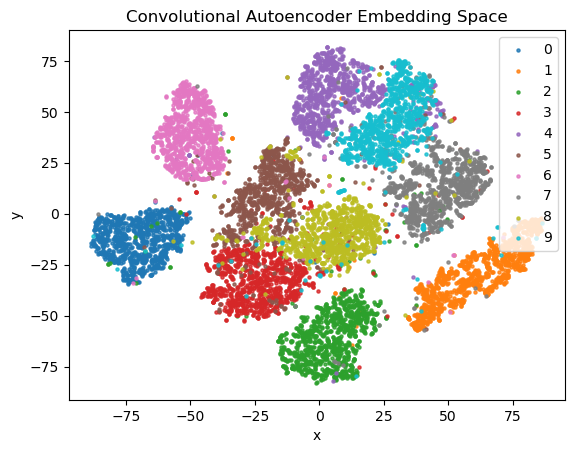

In [35]:
from sklearn.manifold import TSNE

convolutional_autoencoder_encodings = convolutional_autoencoder_encoded_data_per_eval[-1]

convolutional_autoencoder_features = convolutional_autoencoder_encodings[:, :-1]
labels = convolutional_autoencoder_encodings[:, -1].reshape(-1, 1)

tsne = TSNE(n_components=2, n_jobs=-1)
convolutional_autoencoder_compressed = tsne.fit_transform(convolutional_autoencoder_features)

convolutional_autoencoder_encoding = np.hstack((convolutional_autoencoder_compressed, labels))
convolutional_autoencoder_encoding = pd.DataFrame(convolutional_autoencoder_encoding, columns=["x", "y", "class"])
convolutional_autoencoder_encoding = convolutional_autoencoder_encoding.sort_values(by="class")
convolutional_autoencoder_encoding["class"] = convolutional_autoencoder_encoding["class"].astype(int).astype(str)

for label, coordinates in convolutional_autoencoder_encoding.groupby("class"):
    plt.scatter(x=coordinates["x"], y=coordinates["y"], label=label, alpha=0.8, s=5)
plt.title("Convolutional Autoencoder Embedding Space")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()


## Generation

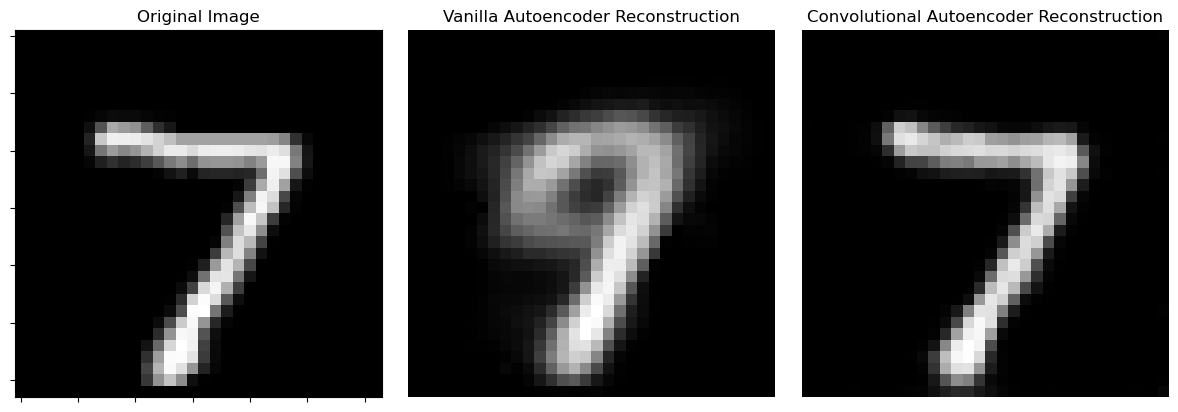

In [36]:
generated_index = 0
image, label = test_dataset[generated_index]

_, recon_vanilla = vanilla_autoencoder(image.unsqueeze(0).to(device))
_, recon_conv = convolutional_autoencoder(image.unsqueeze(0).to(device))

recon_vanilla = recon_vanilla.cpu().detach().numpy()
recon_conv = recon_conv.cpu().detach().numpy()

fig, ax = plt.subplots(1, 3, figsize=(12, 4))

ax[0].imshow(image.squeeze(), cmap="gray")
ax[0].set_title("Original Image")
ax[0].set_xticklabels([])
ax[0].set_yticklabels([])

ax[1].imshow(recon_vanilla.squeeze(), cmap="gray")
ax[1].set_title("Vanilla Autoencoder Reconstruction")
ax[1].set_xticklabels([])
ax[1].set_yticklabels([])
ax[1].axis("off")

ax[2].imshow(recon_conv.squeeze(), cmap="gray")
ax[2].set_title("Convolutional Autoencoder Reconstruction")
ax[2].set_xticklabels([])
ax[2].set_yticklabels([])
ax[2].axis("off")

plt.tight_layout()
plt.show()

It can be seen that convolutional autoencoder has preserved better spatial correlation, and it understands that pixels that are close to each other should have higher correlation.

IndexError: list index out of range

Error in callback <function _draw_all_if_interactive at 0x7feb674914e0> (for post_execute), with arguments args (),kwargs {}:


ValueError: Shape of passed values is (10000, 65), indices imply (10000, 3)

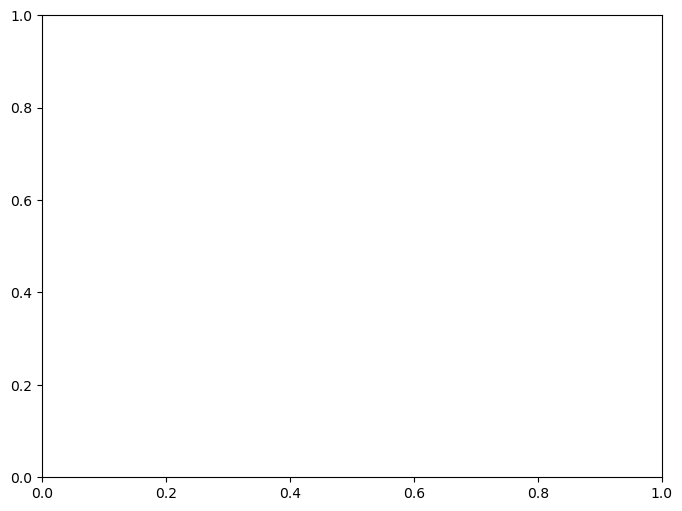

In [37]:
generate_embedding_animation(
    convolutional_autoencoder_encoded_data_per_eval,
    title="Convolutional Autoencoder Embedding Space",
    output_path="results/convolutional_autoencoder_embedding.gif",
    eval_iterations=250,
)

In [ ]:
final_embeddings = convolutional_autoencoder_encoded_data_per_eval[-1]

avg_digit_embeddings = []

for i in range(10):
    avg_embeddings = np.median(final_embeddings[final_embeddings[:, 2] == i][:, :2], axis=0)
    avg_digit_embeddings.append(avg_embeddings)

In [ ]:
avg_digit_embeddings = torch.tensor(np.array(avg_digit_embeddings))
avg_digit_embeddings

tensor([[1.2724, 0.9324],
        [0.5566, 0.2939],
        [0.9639, 0.5865],
        [0.8326, 0.7191],
        [0.6715, 0.8071],
        [0.8624, 0.7310],
        [0.9195, 0.7634],
        [0.5864, 0.7362],
        [0.8338, 0.6675],
        [0.6061, 0.8358]])

This gives the locations of the median embedding locations for each digit.

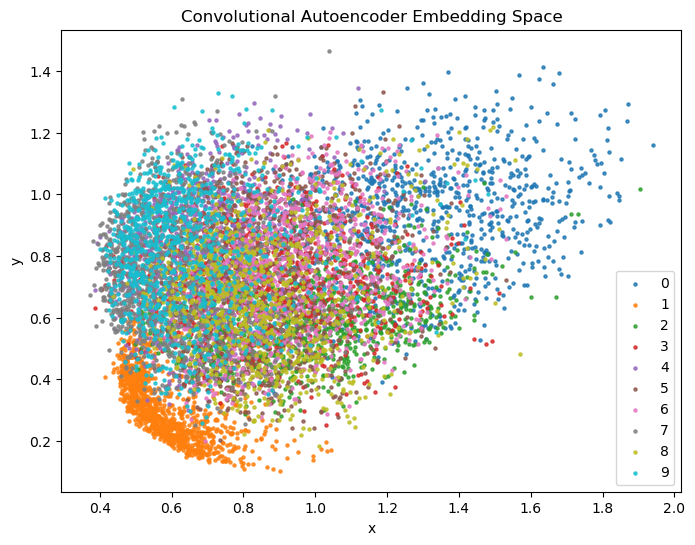

In [ ]:
generate_embedding_animation(final_embeddings, "Convolutional Autoencoder Embedding Space")

In [ ]:
prediction_images = vanilla_autoencoder.decode(avg_digit_embeddings.to(device))
prediction_images

NameError: name 'avg_digit_embeddings' is not defined

In [ ]:
prediction_images.shape

torch.Size([10, 1, 32, 32])

NameError: name 'prediction_images' is not defined

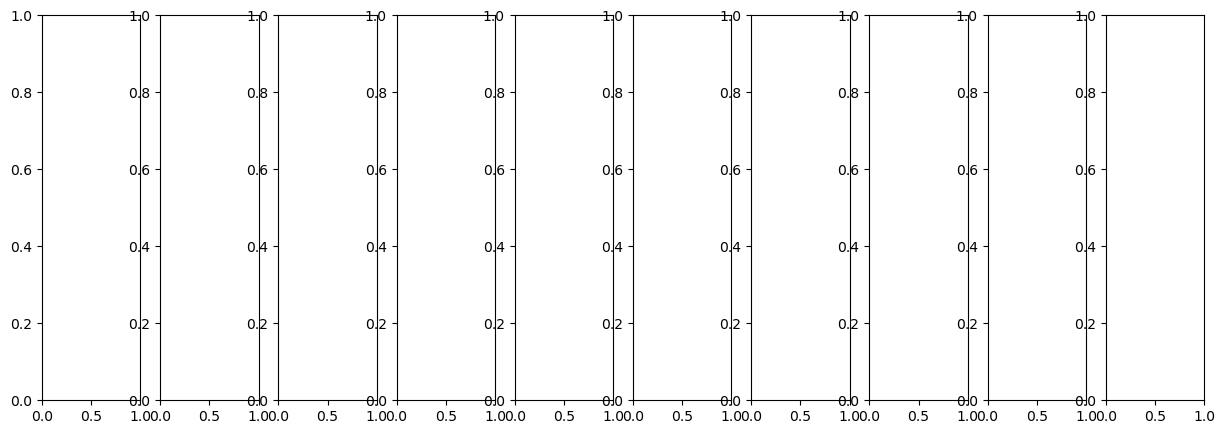

In [ ]:
fig, axes = plt.subplots(1, 10, figsize=(15, 5))

for idx, img in enumerate(prediction_images):
    axes[idx].imshow(img.squeeze().detach().cpu().numpy(), cmap="gray")
    axes[idx].set_xticklabels([])
    axes[idx].set_yticklabels([])
    axes[idx].axis("off")

fig.subplots_adjust(wspace=0, hspace=0)
plt.show()